In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [4]:
df = pd.read_csv("ecommerce_cleaned.csv")

DATA EXPLORATION 

In [5]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Gender,Age,Country,City,Product_Category,Product_Name,Quantity,Unit_Price,Discount,Shipping_Cost,Payment_Method,Sales_Rep,Delivery_Status,Customer_Rating,Clean_Revenue
0,ORD1001,28-Mar-25,CUST501,Esther Ali,Male,55,Germany,Toronto,Electronics,Laptop,2,335,94.0,11,PayPal,Amina,Delivered,1,$587.00
1,ORD1002,25-Mar-25,CUST502,Esther Ali,Female,32,Canada,Hamburg,Fashion,Jeans,1,1199,25.0,50,PayPal,Musa,Pending,1,"$1,224.00"
2,ORD1003,14-Jan-25,CUST503,John Musa,Female,24,Germany,Ottawa,Electronics,T-Shirt,2,490,97.0,26,PayPal,Grace,Returned,3,$909.00
3,ORD1004,17-Apr-25,CUST504,Esther Ali,Female,54,Usa,Berlin,Home,Smart Watch,4,211,70.0,23,Card,Amina,Delivered,2,$797.00
4,ORD1005,17-Apr-25,CUST505,Mary James,Male,41,Nigeria,New York,Electronics,Blender,4,619,58.0,45,PayPal,David,Returned,3,"$2,463.00"


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          199 non-null    object 
 1   Order_Date        198 non-null    object 
 2   Customer_ID       199 non-null    object 
 3   Customer_Name     199 non-null    object 
 4   Gender            199 non-null    object 
 5   Age               199 non-null    int64  
 6   Country           199 non-null    object 
 7   City              199 non-null    object 
 8   Product_Category  199 non-null    object 
 9   Product_Name      199 non-null    object 
 10  Quantity          199 non-null    int64  
 11  Unit_Price        199 non-null    int64  
 12  Discount          198 non-null    float64
 13  Shipping_Cost     199 non-null    int64  
 14  Payment_Method    199 non-null    object 
 15  Sales_Rep         199 non-null    object 
 16  Delivery_Status   199 non-null    object 
 1

In [7]:
df.describe()

,Age,Quantity,Unit_Price,Discount,Shipping_Cost,Customer_Rating
count,199.000000,199.000000,199.000000,198.000000,199.000000,199.000000
mean,39.457286,3.643216,778.095477,50.797980,29.010050,3.110553
std,12.947717,1.672216,401.053620,29.091307,12.605911,1.462611
min,18.000000,-3.000000,51.000000,1.000000,5.000000,1.000000
25%,27.500000,2.000000,439.000000,24.250000,19.000000,2.000000
50%,39.000000,4.000000,777.000000,53.000000,31.000000,3.000000
75%,52.000000,5.000000,1085.000000,75.750000,39.000000,4.000000
max,60.000000,6.000000,1499.000000,100.000000,50.000000,7.000000


In [8]:
df.isnull().sum()

Order_ID            0
Order_Date          1
Customer_ID         0
Customer_Name       0
Gender              0
Age                 0
Country             0
City                0
Product_Category    0
Product_Name        0
Quantity            0
Unit_Price          0
Discount            1
Shipping_Cost       0
Payment_Method      0
Sales_Rep           0
Delivery_Status     0
Customer_Rating     0
Clean_Revenue       0
dtype: int64

In [51]:
df.loc [:, 'Month'] = df['Order_Date'].dt.month_name()

In [53]:
df.loc[:, 'Year'] = df['Order_Date'].dt.year

In [55]:
import seaborn as sns

Data Visualization

In [16]:
# Remove $ sign and commas
df['Clean_Revenue'] = df['Clean_Revenue'].replace('[\$,]', '', regex=True)

# Convert to float first
df['Clean_Revenue'] = df['Clean_Revenue'].astype(float)

# Convert to integer
df['Clean_Revenue'] = df['Clean_Revenue'].astype(int)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          199 non-null    object        
 1   Order_Date        198 non-null    object        
 2   Customer_ID       199 non-null    object        
 3   Customer_Name     199 non-null    object        
 4   Gender            199 non-null    object        
 5   Age               199 non-null    int64         
 6   Country           199 non-null    object        
 7   City              199 non-null    object        
 8   Product_Category  199 non-null    object        
 9   Product_Name      199 non-null    object        
 10  Quantity          199 non-null    int64         
 11  Unit_Price        199 non-null    int64         
 12  Discount          198 non-null    float64       
 13  Shipping_Cost     199 non-null    int64         
 14  Payment_Method    199 non-

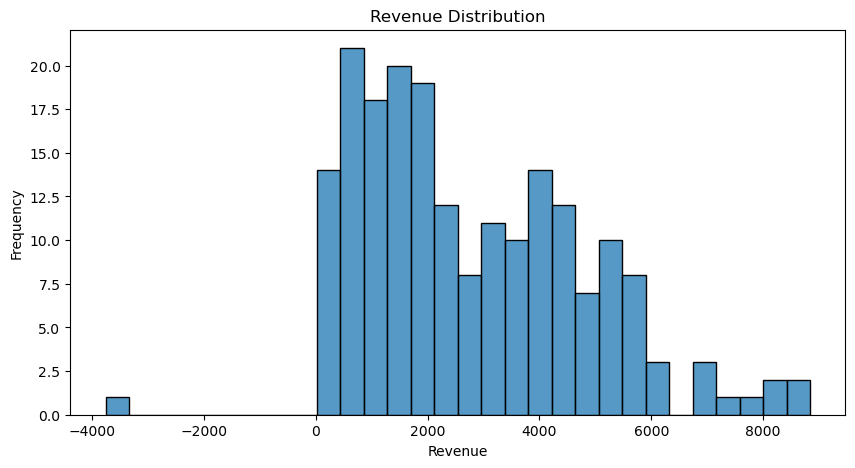

In [74]:
# Revenue Histogram

plt.figure(figsize=(10,5))

sns.histplot(df['Clean_Revenue'], bins=30)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.savefig("Revenue_distribution.png")
plt.show()

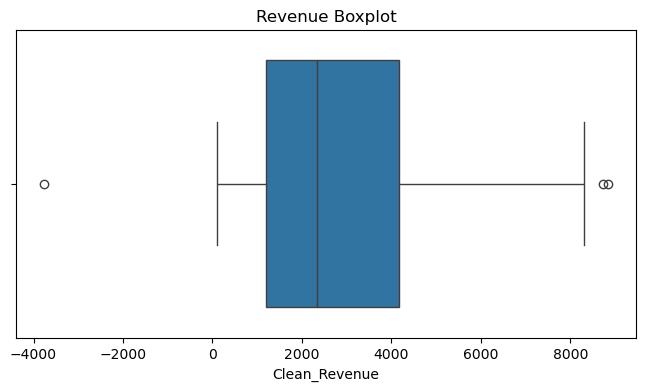

In [57]:
# Revenue Boxplot

plt.figure(figsize=(8,4))

sns.boxplot(x=df['Clean_Revenue'])

plt.title("Revenue Boxplot")

plt.show()

In [59]:
# TOP PRODUCTS ANALYSIS

top_products = df.groupby('Product_Name')['Clean_Revenue'] \
                 .sum() \
                 .sort_values(ascending=False) \
                 .head(10)

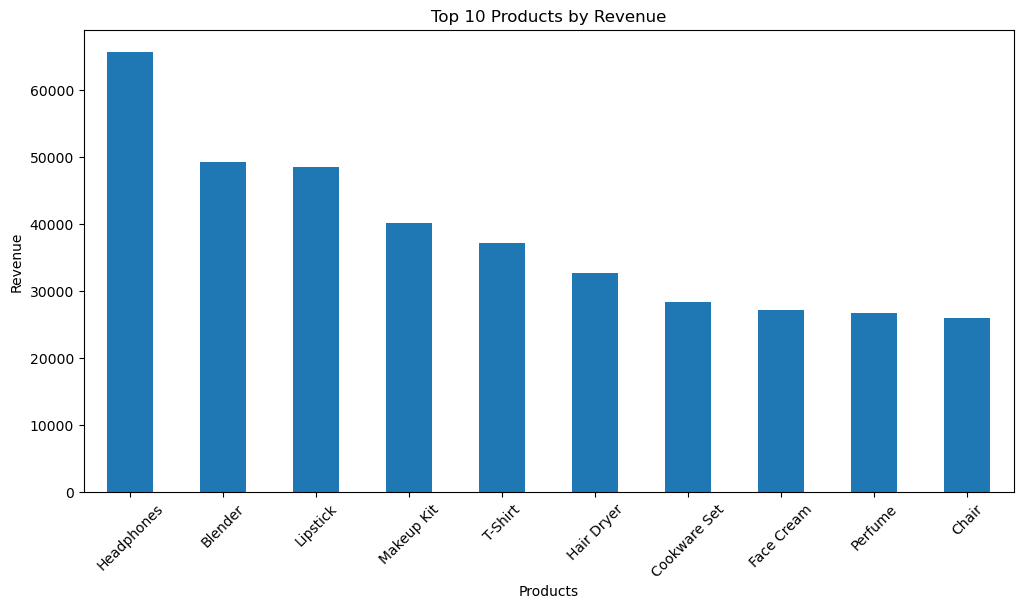

In [60]:
# PLOT TOP PRODUCTS

plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title("Top 10 Products by Revenue")
plt.xlabel("Products")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

In [61]:
# Category Analysis

category_sales = df.groupby('Product_Category')['Clean_Revenue'] \
                   .sum() \
                   .sort_values(ascending=False)

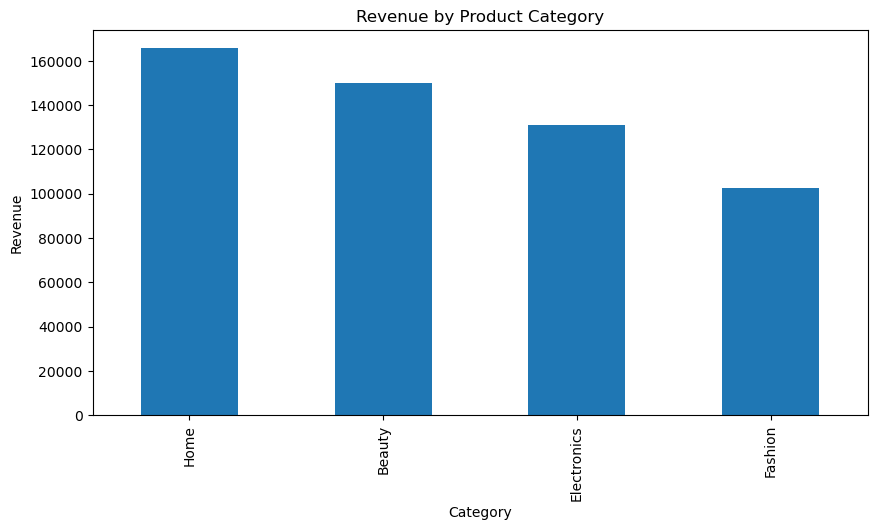

In [62]:
# Top Product Category

plt.figure(figsize=(10,5))

category_sales.plot(kind='bar')

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.show()

In [63]:
# CREATE CORRELATION MATRIX

correlation = df[['Quantity',
                  'Unit_Price',
                  'Discount',
                  'Shipping_Cost',
                  'Clean_Revenue']].corr()

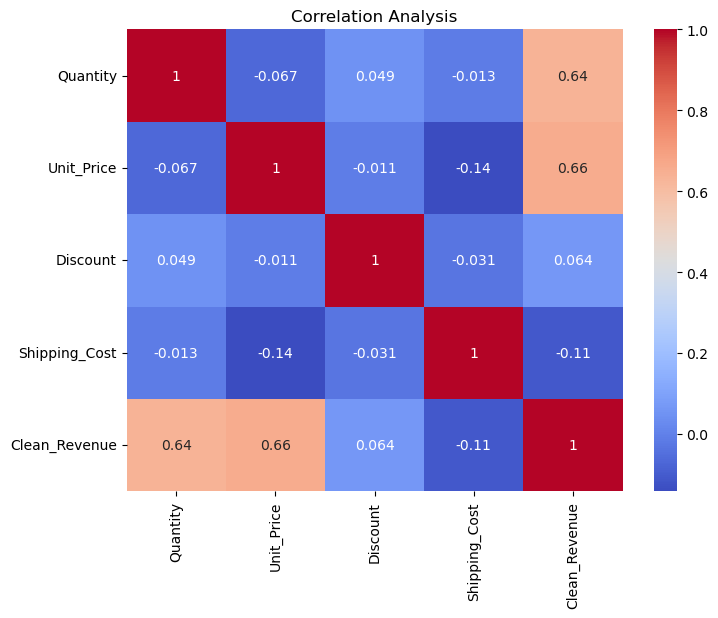

In [73]:
# PLOT HEATMAP

plt.figure(figsize=(8,6))

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Analysis")

plt.savefig("Correlation Analysis.png")

plt.show()

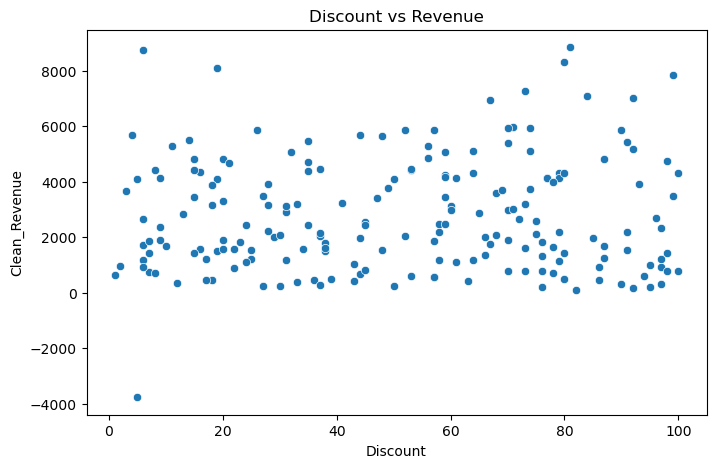

In [65]:
# Discount vs Revenue

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Discount',
    y='Clean_Revenue',
    data=df
)

plt.title("Discount vs Revenue")

plt.show()

In [66]:
# MONTHLY REVENUE TREND

monthly_sales = df.groupby('Month')['Clean_Revenue'] \
                  .sum()

In [67]:
# SORT MONTHS CORRECTLY

month_order = ['January','February','March','April',
               'May','June','July','August',
               'September','October','November','December']

monthly_sales = monthly_sales.reindex(month_order)

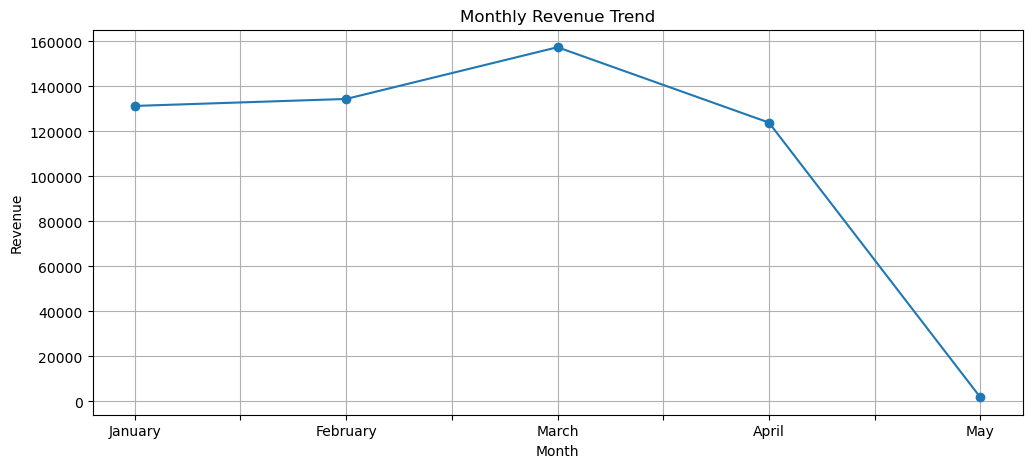

In [68]:
# PLOT MONTHLY TREND

plt.figure(figsize=(12,5))

monthly_sales.plot(marker='o')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

In [69]:
# Country Performance Trend

country_sales = df.groupby('Country')['Clean_Revenue'] \
                  .sum() \
                  .sort_values(ascending=False)

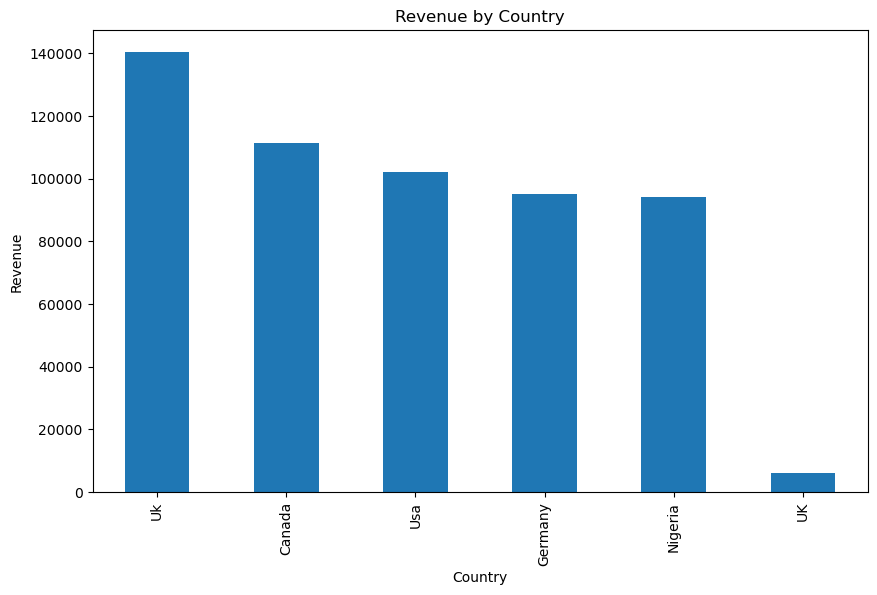

In [70]:
# Revenue by Country

plt.figure(figsize=(10,6))

country_sales.plot(kind='bar')

plt.title("Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.show()

In [71]:
# SALES REPRESENTATIVE PERFORMANCE

sales_rep = df.groupby('Sales_Rep')['Clean_Revenue'] \
              .sum() \
              .sort_values(ascending=False)

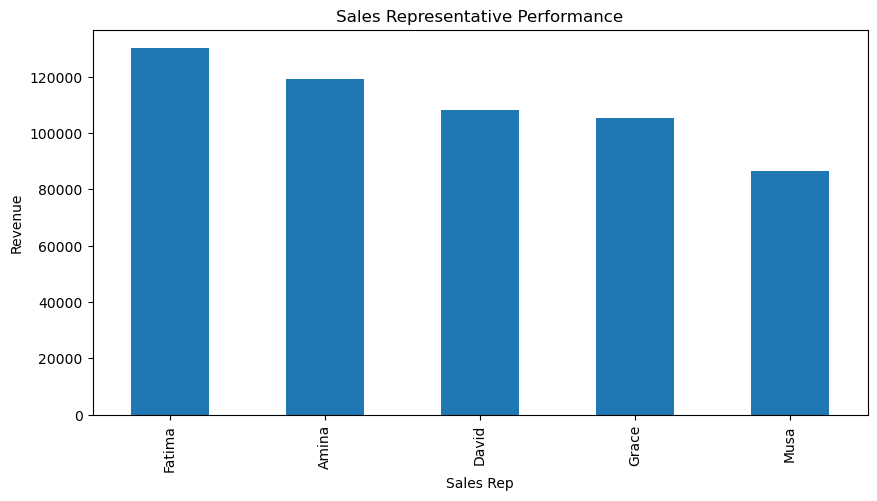

In [72]:
# PLOT SALES REP PERFORMANCE

plt.figure(figsize=(10,5))

sales_rep.plot(kind='bar')

plt.title("Sales Representative Performance")
plt.xlabel("Sales Rep")
plt.ylabel("Revenue")

plt.show()

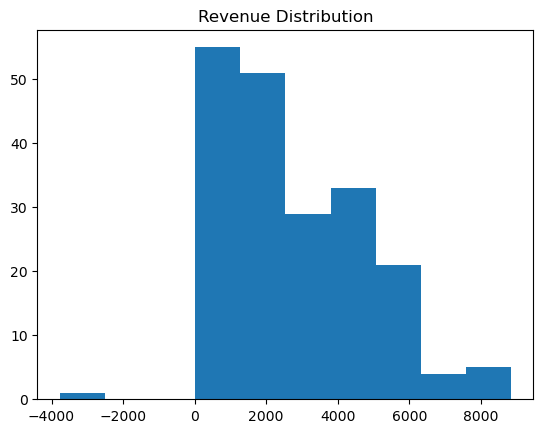

In [17]:
plt.hist(df['Clean_Revenue'])
plt.title("Revenue Distribution")
plt.show()

- Electronics generated highest revenue
- Discounts negatively affected profit margins
- Revenue increased steadily over time
- Some products significantly outperformed others

Machine Learning

In [18]:
df.corr(numeric_only=True)

,Age,Quantity,Unit_Price,Discount,Shipping_Cost,Customer_Rating,Clean_Revenue
Age,1.000000,0.034166,-0.034032,0.033632,-0.050899,-0.092025,-0.027375
Quantity,0.034166,1.000000,-0.062921,0.051005,-0.015163,-0.051936,0.639107
Unit_Price,-0.034032,-0.062921,1.000000,-0.004878,-0.145425,0.052081,0.659564
Discount,0.033632,0.051005,-0.004878,1.000000,-0.040230,-0.045718,0.068646
Shipping_Cost,-0.050899,-0.015163,-0.145425,-0.040230,1.000000,0.035550,-0.112405
Customer_Rating,-0.092025,-0.051936,0.052081,-0.045718,0.035550,1.000000,0.046939
Clean_Revenue,-0.027375,0.639107,0.659564,0.068646,-0.112405,0.046939,1.000000


In [36]:
X = df[['Quantity','Unit_Price','Discount',
        'Shipping_Cost','Customer_Rating']]

In [37]:
y = df['Clean_Revenue']

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [39]:
from sklearn.linear_model import LinearRegression

In [40]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [41]:
predictions = model.predict(X_test)

In [42]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)

print(mae)

584.5837521517478


In [43]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, predictions)

print(r2)

0.8820102689432067


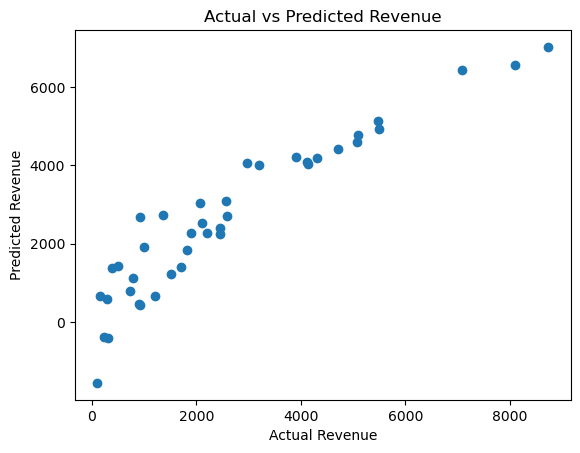

In [44]:
plt.scatter(y_test, predictions)
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue")
plt.show()

In [45]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False
